# 泰勒展开是什么 - 可视化

本 Notebook 生成三张图：
1. 局部线性近似（切线）
2. 一阶与二阶近似对比
3. e^x 的多阶泰勒近似

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/00_先修专题/01_泰勒展开/assets')

## 图1：局部线性近似（切线）

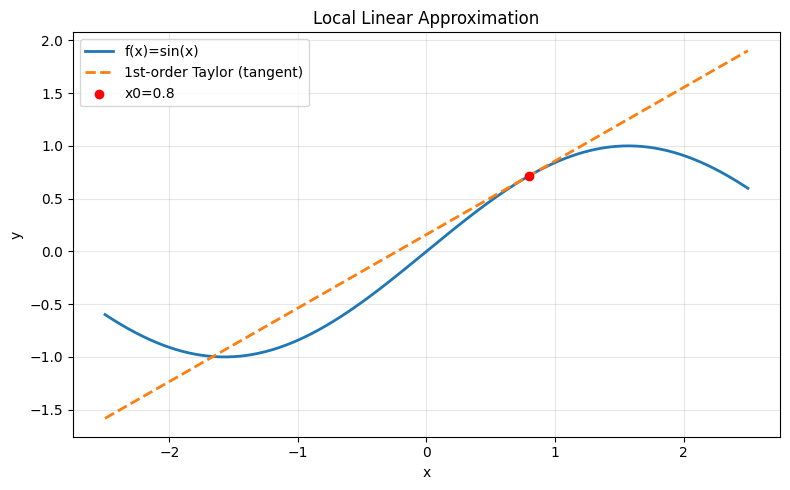

In [2]:
f = lambda x: np.sin(x)
df = lambda x: np.cos(x)

x0 = 0.8
x = np.linspace(-2.5, 2.5, 500)

y0 = f(x0)
k = df(x0)
tangent = y0 + k*(x-x0)

plt.figure(figsize=(8,5))
plt.plot(x, f(x), label='f(x)=sin(x)', linewidth=2)
plt.plot(x, tangent, '--', label='1st-order Taylor (tangent)', linewidth=2)
plt.scatter([x0], [y0], c='red', zorder=5, label=f'x0={x0}')
plt.title('Local Linear Approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '01_local_linear.png', dpi=160)
plt.show()

## 图2：一阶与二阶近似对比

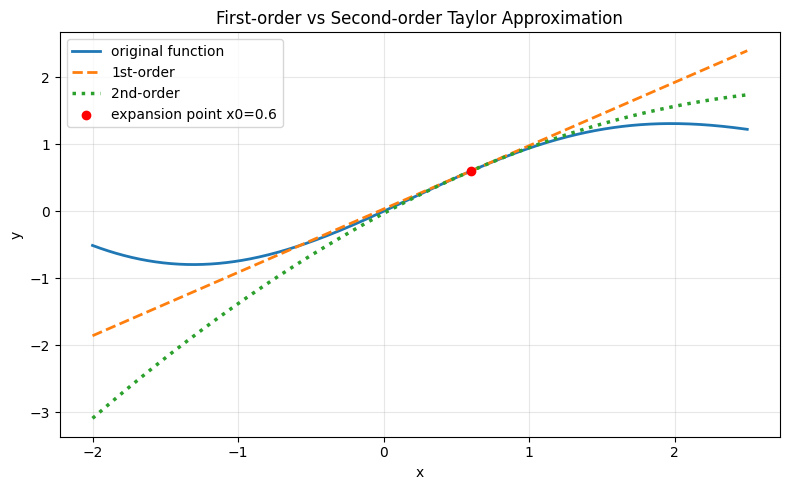

In [3]:
f = lambda x: np.sin(x) + 0.1*x**2
df = lambda x: np.cos(x) + 0.2*x
ddf = lambda x: -np.sin(x) + 0.2

x0 = 0.6
x = np.linspace(-2.0, 2.5, 500)

f0 = f(x0)
t1 = f0 + df(x0)*(x-x0)
t2 = f0 + df(x0)*(x-x0) + 0.5*ddf(x0)*(x-x0)**2

plt.figure(figsize=(8,5))
plt.plot(x, f(x), label='original function', linewidth=2)
plt.plot(x, t1, '--', label='1st-order', linewidth=2)
plt.plot(x, t2, ':', label='2nd-order', linewidth=2.5)
plt.scatter([x0],[f0], c='red', zorder=5, label=f'expansion point x0={x0}')
plt.title('First-order vs Second-order Taylor Approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '02_higher_order_compare.png', dpi=160)
plt.show()

## 图3：e^x 的多阶泰勒近似

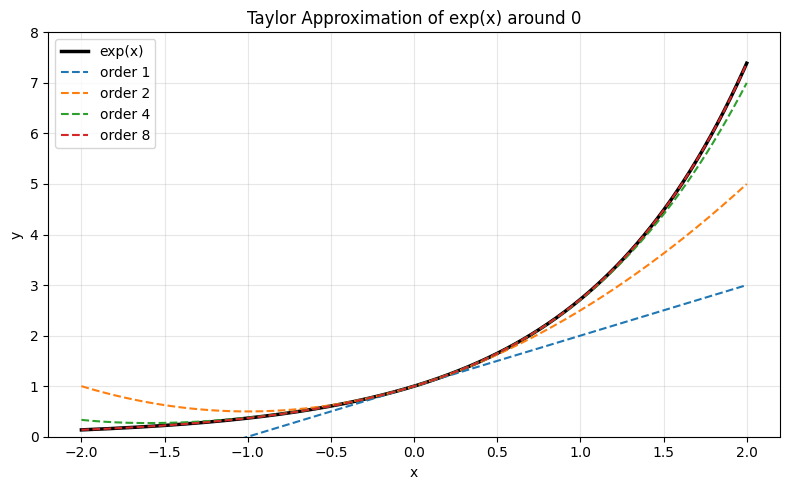

In [4]:
x = np.linspace(-2, 2, 500)
true_y = np.exp(x)

def taylor_exp(x, order):
    s = np.zeros_like(x, dtype=float)
    fact = 1.0
    power = np.ones_like(x, dtype=float)
    for n in range(order + 1):
        if n > 0:
            fact *= n
            power *= x
        s += power / fact
    return s

orders = [1, 2, 4, 8]

plt.figure(figsize=(8,5))
plt.plot(x, true_y, label='exp(x)', linewidth=2.5, color='black')
for o in orders:
    plt.plot(x, taylor_exp(x, o), '--', label=f'order {o}')

plt.ylim(0, 8)
plt.title('Taylor Approximation of exp(x) around 0')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '03_exp_approx.png', dpi=160)
plt.show()

### 输出文件
- `assets/01_local_linear.png`
- `assets/02_higher_order_compare.png`
- `assets/03_exp_approx.png`